# 자치구 생활인구 + 이송건수 통합 예측

## 목표

**자치구별 생활인구와 환자 이송건수의 관계** 확인

분석 순서
1. 학습기간에서 이송건수와 연관성이 있는 생활인구 컬럼을 확인
2. 기존 이송 예측 특성과 생활인구 특성을 하나의 DataFrame으로 통합
3. 자치구별 `인구 대비 이송률`을 **학습기간만 사용하여** 생성
4. 동일한 테스트 데이터에서 기존 모델과 통합 모델 비교
5. 기존 기준인 **94%** 와 비교

### 중요
- 미래 정보 누수를 막기 위해 자치구별 이송률은 2025년 테스트 데이터를 사용하지 않고 학습기간에서만 계산합니다.
- 정확도는 기존 프로젝트와 동일하게 `100 - MAPE(%)`로 계산합니다.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)
# 한글 폰트 자동 선택
font_candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR', 'Noto Sans CJK JP']
installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in installed_fonts), None)
if selected_font:
    plt.rcParams['font.family'] = selected_font
else:
    print('[주의] 한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.')
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 30)

TEST_START = pd.Timestamp('2025-01-01')
REFERENCE_ACCURACY = 94.0
PREVIOUS_BEST = 95.230816

print('테스트 시작일:', TEST_START.date())

테스트 시작일: 2025-01-01


In [2]:
# 1. 데이터 로드
df = pd.read_csv('C:/ai/source/09_Project/cheolhyeon_jo/ml_data/transport_dataset.csv')
df['ds'] = pd.to_datetime(df['ds'])

print('데이터:', df.shape)
print('기간:', df['ds'].min().date(), '~', df['ds'].max().date())
print('자치구 수:', df['District'].nunique())
display(df.head())

데이터: (2564, 46)
기간: 2017-01-01 ~ 2025-12-01
자치구 수: 25


,ds,District,연도,월,전월_transport_cnt,전년동월_y,전년동월_transport_cnt,전월_total_pop,전월_내국인생활인구수,전월_장기체류외국인인구수,전월_단기체류외국인인구수,전월_일최대인구수,전월_일최소인구수,전월_day_pop,전월_night_pop,...,전년_잠금장치개방,전년_폭발사고,전년_화재,전년_총입원연인원,전년_서울내입원연인원,전년_서울외유출연인원,전년_유출률,전년_응급실입원연인원,전년_총처리연인원,전년_서울내환자연인원,전년_서울외유입연인원,전년_유입률,전년_응급실처리연인원,출처,transport_cnt
0,2017-01-01,강남구,2017,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API,1472.0
1,2017-02-01,강남구,2017,2,1472.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API,1255.0
2,2017-03-01,강남구,2017,3,1255.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API,1438.0
3,2017-04-01,강남구,2017,4,1438.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API,1512.0
4,2017-05-01,강남구,2017,5,1512.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,API,1543.0


## 1. 생활인구 관련 컬럼의 연관성 확인

컬럼 선택에 테스트 데이터가 개입하지 않도록 **2025년 이전 학습 데이터에서만 상관계수**를 계산합니다.

이번 데이터에서 생활인구 관련 컬럼 중 `|Pearson r| >= 0.30`인 변수들을 후보로 사용합니다.


In [3]:
# 2. 생활인구 후보 컬럼
population_candidates = [
    c for c in df.columns
    if c.startswith('전월_')
    and ('pop' in c or '인구' in c)
    and c != '전월_transport_cnt'
]

train_for_corr = df[df['ds'] < TEST_START].copy()

corr = (
    train_for_corr[population_candidates + ['transport_cnt']]
    .corr(numeric_only=True)['transport_cnt']
    .drop('transport_cnt')
    .sort_values(key=abs, ascending=False)
)

corr_table = corr.rename('Pearson_r').to_frame()
corr_table['abs_r'] = corr_table['Pearson_r'].abs()
corr_table['선택'] = corr_table['abs_r'] >= 0.30

display(corr_table.round(4))

,Pearson_r,abs_r,선택
전월_night_pop,0.6925,0.6925,True
전월_내국인생활인구수,0.6586,0.6586,True
전월_일최소인구수,0.6542,0.6542,True
전월_동일자치구행정동간이동인구수,0.6487,0.6487,True
전월_total_pop,0.6479,0.6479,True
전월_일최대인구수,0.5971,0.5971,True
전월_day_pop,0.5495,0.5495,True
전월_일최대이동인구수,0.4068,0.4068,True
전월_서울외유입인구수,0.3400,0.3400,True
전월_자치구간이동인구수,0.1368,0.1368,False


In [4]:
# 3. 상관계수 0.30 이상 생활인구 컬럼 선택
POP_FEATURES = corr_table[corr_table['선택']].index.tolist()

print('선택된 생활인구 특성:', len(POP_FEATURES))
for c in POP_FEATURES:
    print(f'- {c}: r={corr_table.loc[c, "Pearson_r"]:.3f}')

선택된 생활인구 특성: 9
- 전월_night_pop: r=0.692
- 전월_내국인생활인구수: r=0.659
- 전월_일최소인구수: r=0.654
- 전월_동일자치구행정동간이동인구수: r=0.649
- 전월_total_pop: r=0.648
- 전월_일최대인구수: r=0.597
- 전월_day_pop: r=0.549
- 전월_일최대이동인구수: r=0.407
- 전월_서울외유입인구수: r=0.340


## 2. 이송 관련 특성과 생활인구 특성 결합

기존 예측에서 사용하던 핵심 이송 관련 특성을 기준으로 합니다.

- 전월 이송건수
- 전년 동월 이송건수
- 전년 동월 환자수 관련 값
- 전년도 인명갇힘
- 전년도 승강기사고
- 월

여기에 선택된 생활인구 변수를 결합합니다.


In [5]:
# 4. 기존 이송 관련 핵심 특성
BASE_FEATURES = [
    '월',
    '전월_transport_cnt',
    '전년동월_transport_cnt',
    '전년동월_y',
    '전년_인명갇힘',
    '전년_승강기사고'
]

# 모든 모델을 정확히 같은 행에서 비교하기 위해
# 기본+인구 특성이 모두 존재하는 행만 사용
model_df = df.dropna(
    subset=BASE_FEATURES + POP_FEATURES + ['transport_cnt']
).copy()

train = model_df[model_df['ds'] < TEST_START].copy()
test = model_df[model_df['ds'] >= TEST_START].copy()

print('학습:', train.shape, train['ds'].min().date(), '~', train['ds'].max().date())
print('테스트:', test.shape, test['ds'].min().date(), '~', test['ds'].max().date())

학습: (1880, 46) 2018-05-01 ~ 2024-12-01
테스트: (300, 46) 2025-01-01 ~ 2025-12-01


## 3. 자치구별 인구 대비 이송률 특성

단순 인구수만 사용하는 것보다 **같은 인구 규모에서도 자치구마다 이송 수요가 다를 수 있음**을 반영합니다.

학습기간에서만:

`자치구별 이송률 = transport_cnt / 전월_night_pop`

을 계산합니다.

그리고:

`인구기반 예상 이송 = 현재 전월 야간생활인구 × 자치구별 이송률`

을 생성합니다.

이 값은 테스트 정답을 사용하지 않으므로 미래 정보 누수를 피합니다.


In [6]:
# 5. 학습 데이터에서만 자치구별 인구-이송 관계 생성
KEY_POP = '전월_night_pop'

district_rate = (
    (train['transport_cnt'] / train[KEY_POP])
    .groupby(train['District'])
    .mean()
)

for data in [train, test]:
    data['구별_이송률'] = data['District'].map(district_rate)
    data['인구기반_예상이송'] = data[KEY_POP] * data['구별_이송률']

print('자치구별 인구 1만 명당 평균 이송건수(학습기간 기준)')
display((district_rate * 10000).sort_values(ascending=False).rename('1만명당_이송건수').to_frame())

자치구별 인구 1만 명당 평균 이송건수(학습기간 기준)


,1만명당_이송건수
District,
강북구,34.252548
구로구,32.385303
도봉구,30.239105
중구,29.365493
종로구,29.363565
양천구,29.273413
중랑구,28.961657
금천구,27.818983
마포구,26.747539


## 4. 하나의 통합 DataFrame

요청한 두 주제의 컬럼을 한 데이터프레임으로 묶습니다.

`통합 특성 = 이송 관련 특성 + 생활인구 관련 특성 + 자치구별 인구기반 특성`


In [7]:
# 6. 통합 데이터프레임
INTEGRATED_FEATURES = (
    BASE_FEATURES
    + POP_FEATURES
    + ['구별_이송률', '인구기반_예상이송']
)

integrated_train = train[
    ['ds', 'District'] + INTEGRATED_FEATURES + ['transport_cnt']
].copy()

integrated_test = test[
    ['ds', 'District'] + INTEGRATED_FEATURES + ['transport_cnt']
].copy()

print('통합 학습 데이터:', integrated_train.shape)
print('통합 테스트 데이터:', integrated_test.shape)
display(integrated_train.head())

integrated_all = pd.concat([integrated_train, integrated_test]).sort_values(['District','ds'])
integrated_all.to_csv(
    'C:/ai/source/09_Project/cheolhyeon_jo/new_predict/transport_population_integrated_dataset.csv',
    index=False,
    encoding='utf-8-sig'
)
print('저장: transport_population_integrated_dataset.csv')

통합 학습 데이터: (1880, 20)
통합 테스트 데이터: (300, 20)


,ds,District,월,전월_transport_cnt,전년동월_transport_cnt,전년동월_y,전년_인명갇힘,전년_승강기사고,전월_night_pop,전월_내국인생활인구수,전월_일최소인구수,전월_동일자치구행정동간이동인구수,전월_total_pop,전월_일최대인구수,전월_day_pop,전월_일최대이동인구수,전월_서울외유입인구수,구별_이송률,인구기반_예상이송,transport_cnt
16,2018-05-01,강남구,5,1508.0,1543.0,2650.0,337,580,749100.867912,817036.388088,685937.442423,133339.751896,858066.564081,1.049526e+06,1.010619e+06,653647.984012,196616.752173,0.001934,1448.509958,1660.0
17,2018-06-01,강남구,6,1660.0,1643.0,2773.0,337,580,740797.242668,805368.125755,680210.682961,127280.065213,846701.268194,1.029229e+06,9.920160e+05,623595.221558,188246.487816,0.001934,1432.453530,1673.0
18,2018-07-01,강남구,7,1673.0,1691.0,2963.0,337,580,748014.667740,815268.165837,686486.655720,120738.499310,855382.445667,1.045680e+06,1.005697e+06,600353.007910,185564.330910,0.001934,1446.409611,1822.0
19,2018-08-01,강남구,8,1822.0,1584.0,2727.0,337,580,757553.900203,834267.359229,690608.991013,123926.464484,877646.702832,1.091580e+06,1.045777e+06,639512.318181,203945.091526,0.001934,1464.855289,1743.0
20,2018-09-01,강남구,9,1743.0,1618.0,2755.0,337,580,747578.232010,822891.072045,685601.723587,131861.267119,864336.716265,1.068191e+06,1.025317e+06,647877.527045,198686.910484,0.001934,1445.565690,1514.0


저장: transport_population_integrated_dataset.csv


## 5. 공정한 모델 비교

세 모델을 **동일한 학습/테스트 행**에서 비교합니다.

1. `기존`: 이송 관련 특성만
2. `기존+인구`: 상관성이 확인된 생활인구 특성 추가
3. `통합`: 생활인구 + 자치구별 인구 대비 이송률까지 추가

모델은 기존 결과에서 성능이 좋았던 Gradient Boosting을 사용합니다.


In [8]:
# 7. 평가 함수
def evaluate(name, y_true, pred):
    mape = mean_absolute_percentage_error(y_true, pred)
    return {
        '모델': name,
        '정확도(%)': 100 * (1 - mape),
        'R2': r2_score(y_true, pred),
        'MAE': mean_absolute_error(y_true, pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, pred))
    }

FEATURE_SETS = {
    '기존': BASE_FEATURES,
    '기존+인구': BASE_FEATURES + POP_FEATURES,
    '통합(인구+구별이송률)': INTEGRATED_FEATURES
}

results = []
models = {}
predictions = {}

for name, features in FEATURE_SETS.items():
    # 통합 특성은 기본 GradientBoosting이 더 안정적으로 좋았고,
    # 기본/인구 모델은 동일한 모델 조건으로 비교합니다.
    model = GradientBoostingRegressor(random_state=10)
    model.fit(train[features], train['transport_cnt'])
    pred = model.predict(test[features])

    results.append(evaluate(name, test['transport_cnt'], pred))
    models[name] = model
    predictions[name] = pred

result_df = pd.DataFrame(results)
display(result_df.round(4))

,모델,정확도(%),R2,MAE,RMSE
0,기존,95.0438,0.9374,44.3076,56.1995
1,기존+인구,95.2434,0.9428,42.4444,53.6949
2,통합(인구+구별이송률),95.2538,0.9443,42.2721,52.9937


## 6. 기존 94% 모델의 결과값과 비교


In [9]:
# 8. 개선폭 계산
result_df['94%대비_개선(%p)'] = result_df['정확도(%)'] - REFERENCE_ACCURACY

baseline_acc = result_df.loc[result_df['모델']=='기존', '정확도(%)'].iloc[0]
result_df['동일조건_기존대비_개선(%p)'] = result_df['정확도(%)'] - baseline_acc

display(result_df.round(4))

best = result_df.loc[result_df['정확도(%)'].idxmax()]
print('===== 핵심 결과 =====')
print(f"최고 모델: {best['모델']}")
print(f"정확도: {best['정확도(%)']:.3f}%")
print(f"94% 기준 대비: +{best['94%대비_개선(%p)']:.3f}%p")
print(f"동일 데이터의 기존 모델 대비: {best['동일조건_기존대비_개선(%p)']:+.3f}%p")
print(f"MAE: {best['MAE']:.2f}건")
print(f"R²: {best['R2']:.4f}")

,모델,정확도(%),R2,MAE,RMSE,94%대비_개선(%p),동일조건_기존대비_개선(%p)
0,기존,95.0438,0.9374,44.3076,56.1995,1.0438,0.0000
1,기존+인구,95.2434,0.9428,42.4444,53.6949,1.2434,0.1997
2,통합(인구+구별이송률),95.2538,0.9443,42.2721,52.9937,1.2538,0.2100


===== 핵심 결과 =====
최고 모델: 통합(인구+구별이송률)
정확도: 95.254%
94% 기준 대비: +1.254%p
동일 데이터의 기존 모델 대비: +0.210%p
MAE: 42.27건
R²: 0.9443


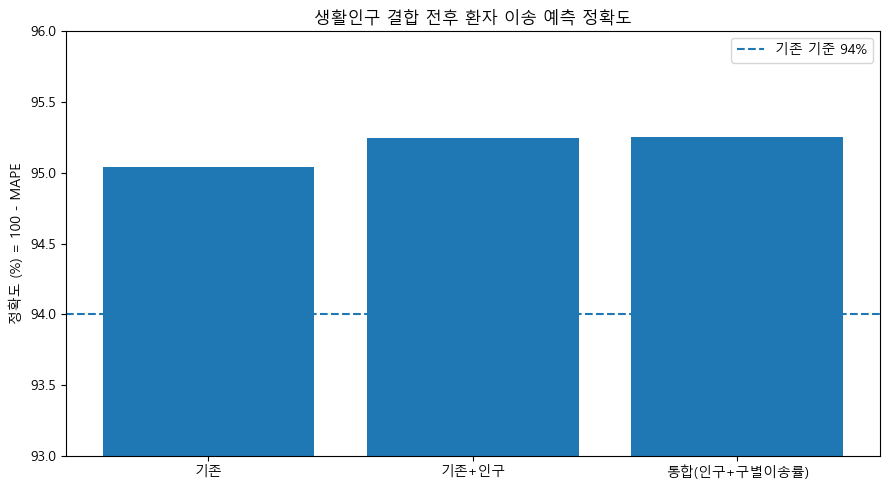

In [10]:
# 9. 성능 비교 그래프
plot_df = result_df.copy()

plt.figure(figsize=(9,5))
plt.bar(plot_df['모델'], plot_df['정확도(%)'])
plt.axhline(94, linestyle='--', label='기존 기준 94%')
plt.ylim(93, max(96, plot_df['정확도(%)'].max()+0.3))
plt.title('생활인구 결합 전후 환자 이송 예측 정확도')
plt.ylabel('정확도 (%) = 100 - MAPE')
plt.xlabel('')
plt.legend()
plt.tight_layout()
plt.show()

## 7. 통합 모델에서 어떤 특성이 중요한가?

생활인구 컬럼을 많이 추가했다고 해서 모두 중요한 것은 아닙니다.  
Gradient Boosting의 특성 중요도를 확인하여 실제 예측에 많이 사용된 변수를 봅니다.


,importance
전월_transport_cnt,0.8595
전년동월_y,0.0497
월,0.0375
인구기반_예상이송,0.0324
전년동월_transport_cnt,0.0090
전년_승강기사고,0.0030
전년_인명갇힘,0.0029
전월_동일자치구행정동간이동인구수,0.0020
전월_night_pop,0.0010
전월_내국인생활인구수,0.0007


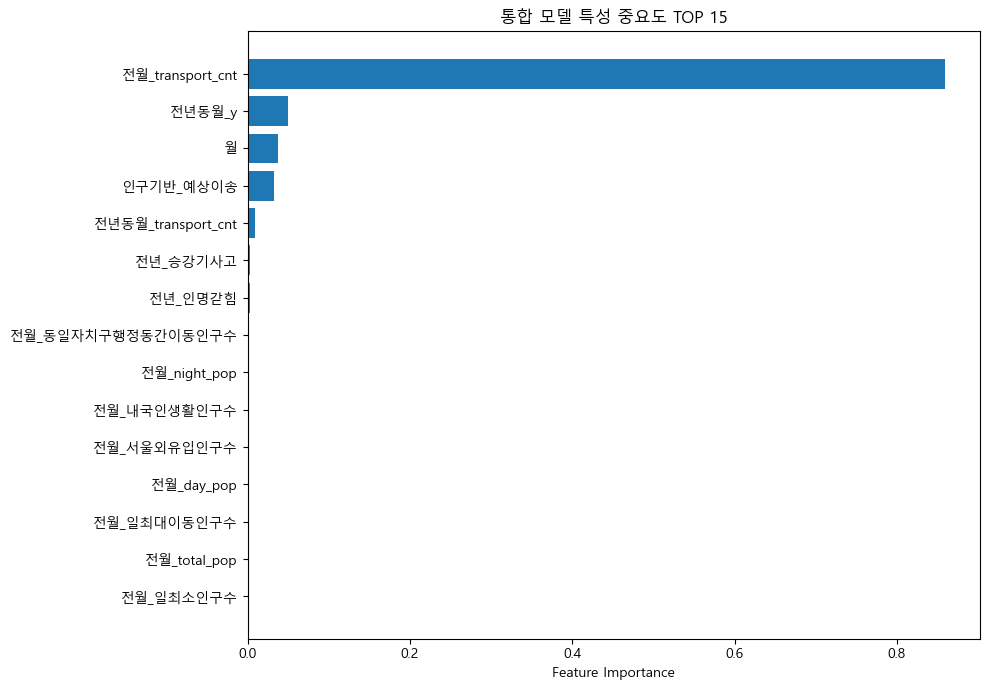

In [11]:
# 10. 통합 모델 특성 중요도
integrated_model = models['통합(인구+구별이송률)']

importance = (
    pd.Series(
        integrated_model.feature_importances_,
        index=INTEGRATED_FEATURES,
        name='importance'
    )
    .sort_values(ascending=False)
)

display(importance.to_frame().head(15).round(4))

plt.figure(figsize=(10,7))
top_imp = importance.head(15).sort_values()
plt.barh(top_imp.index, top_imp.values)
plt.title('통합 모델 특성 중요도 TOP 15')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()


## 8. 테스트 실제값 vs 예측값 시각화

최종 통합 모델의 테스트 예측 결과를 자치구별 시계열로 비교합니다.

- 파란 실선: 실제 이송건수
- 빨간 점선: 예측 이송건수
- 그래프가 서로 가까울수록 실제값을 잘 예측한 것입니다.
- 기본값은 테스트 기간 평균 이송건수가 큰 상위 4개 자치구입니다.

`TOP_N` 값을 바꾸면 표시할 자치구 수를 변경할 수 있습니다.


시각화 대상 자치구: ['강남구', '강서구', '구로구', '송파구', '노원구', '양천구', '강동구', '마포구', '관악구', '영등포구']


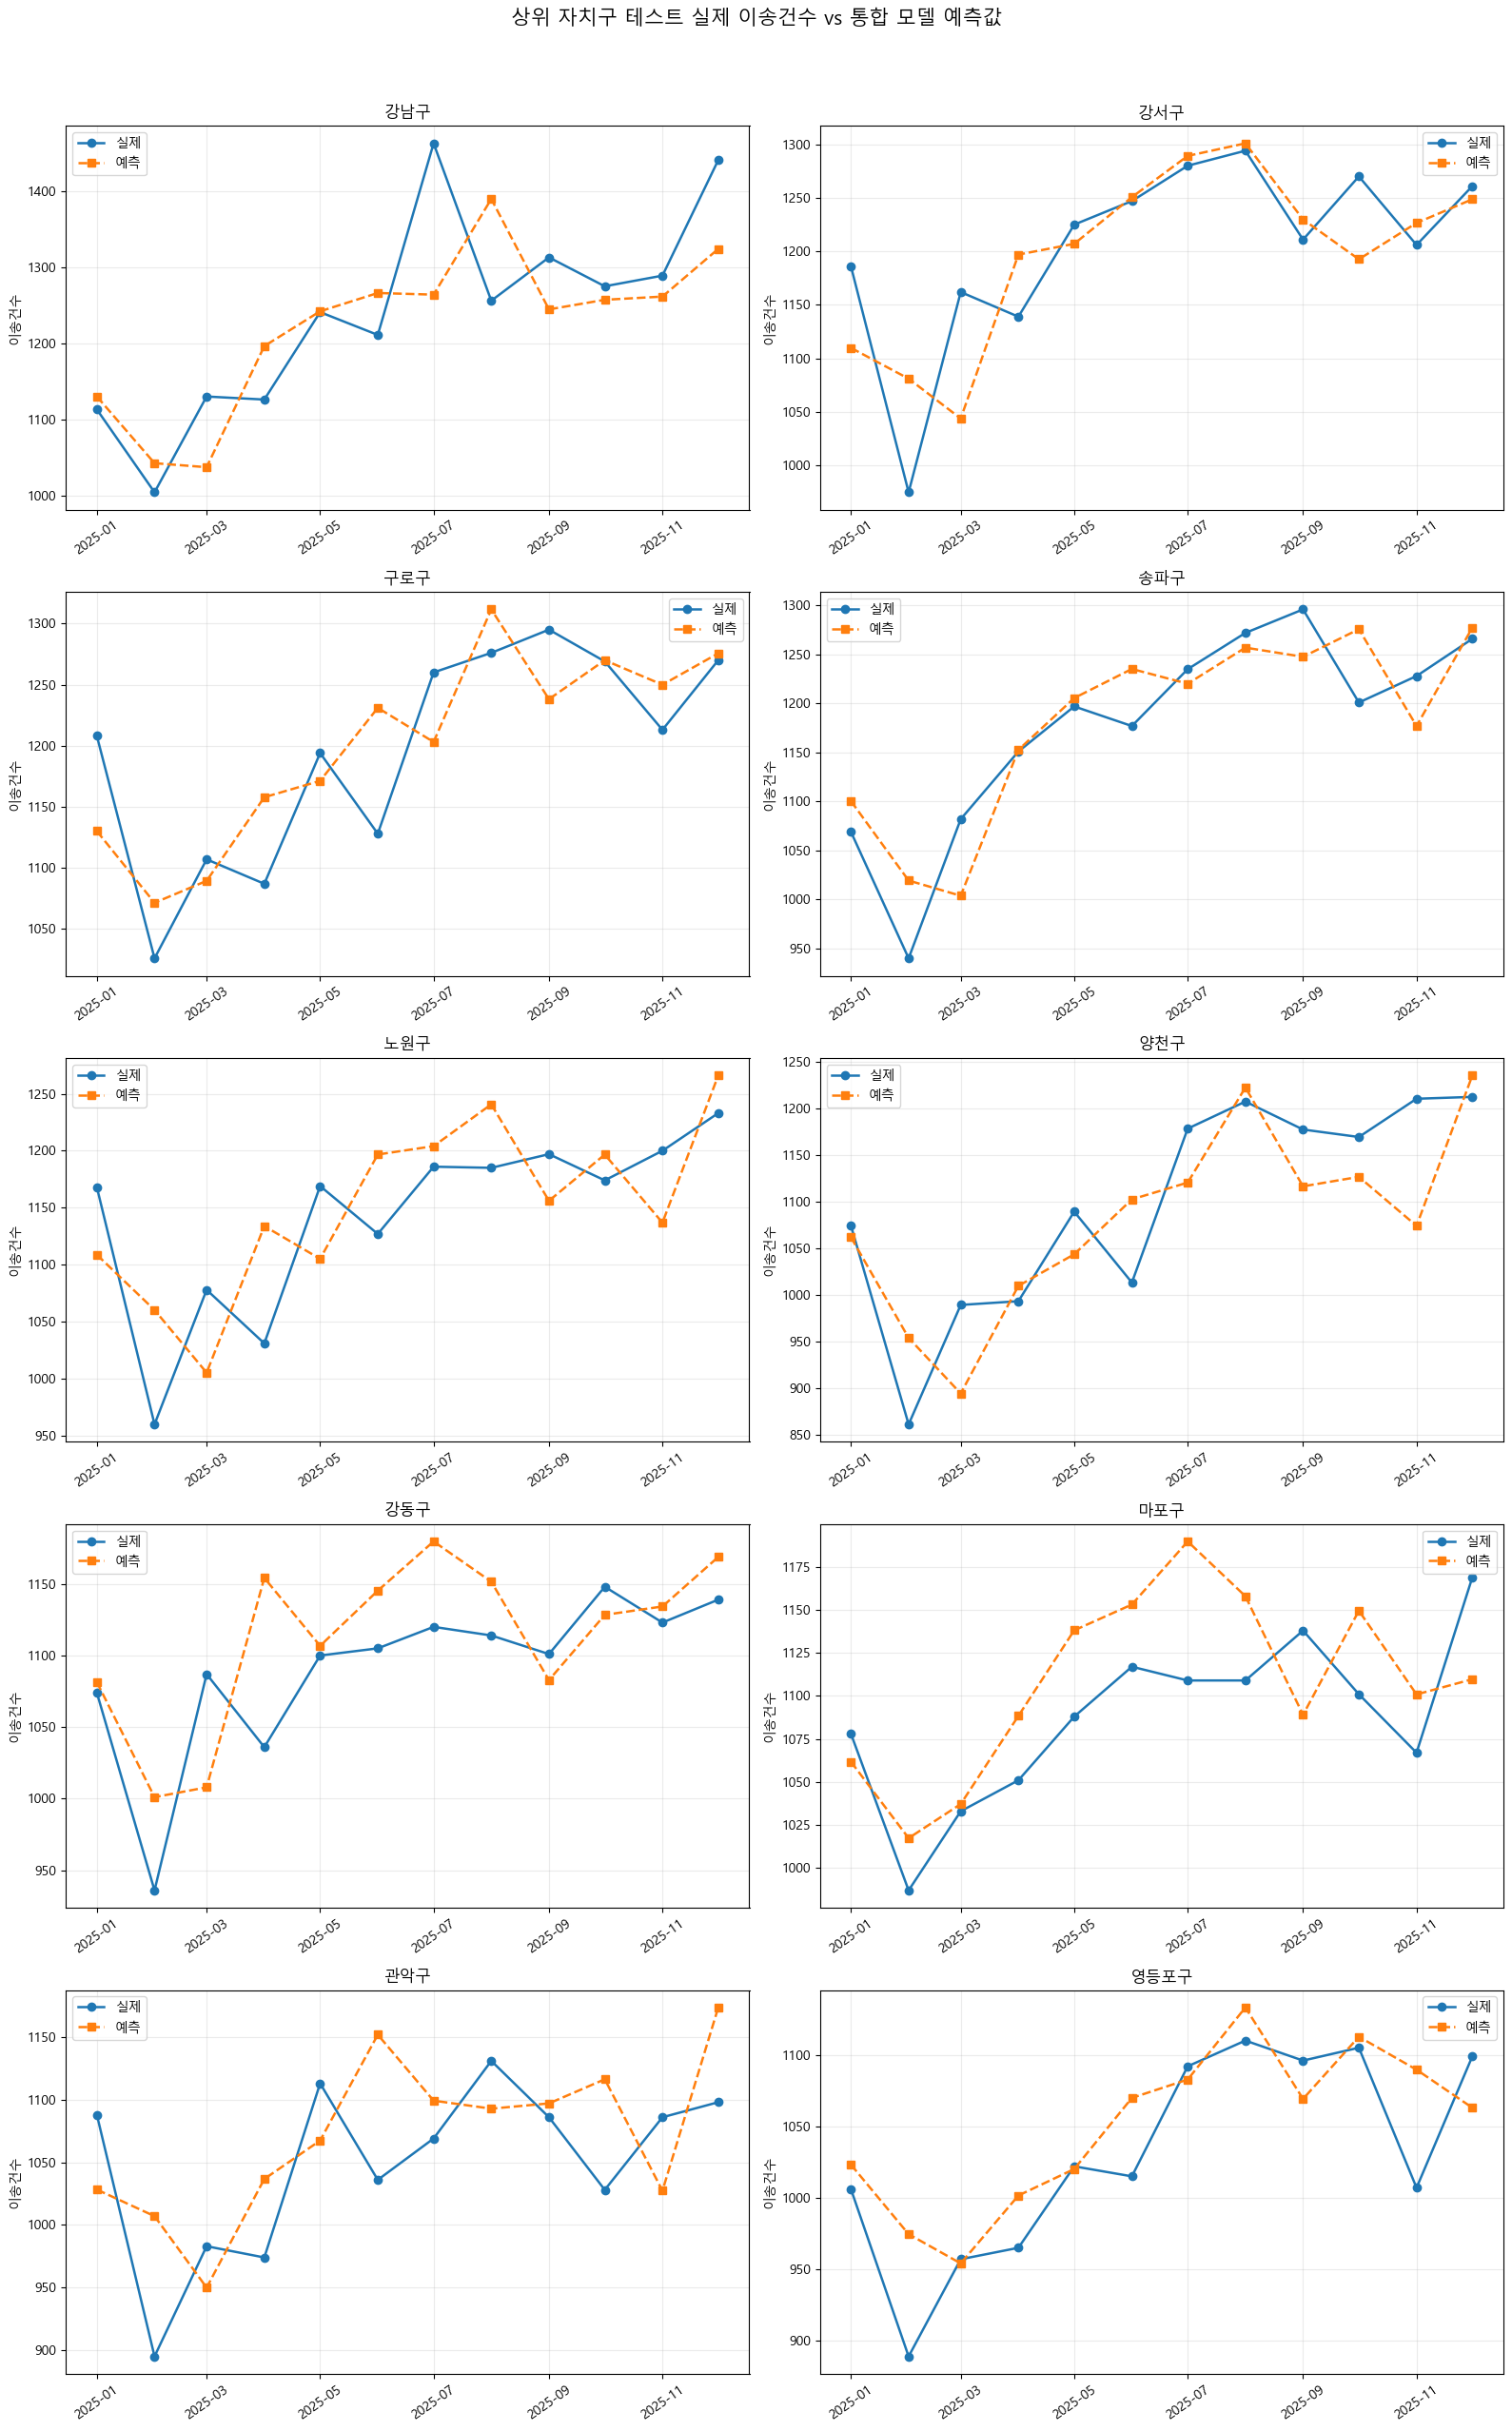

In [12]:
# 11. 테스트 실제값 vs 예측값 시각화

FINAL_MODEL_NAME = '통합(인구+구별이송률)'
TOP_N = 10

# 테스트 데이터에 최종 모델 예측값 추가
test_viz = test[['ds', 'District', 'transport_cnt']].copy()
test_viz['predicted_transport_cnt'] = predictions[FINAL_MODEL_NAME]

# 테스트 기간 실제 이송건수 평균이 높은 자치구 선택
top_districts = (
    test_viz.groupby('District')['transport_cnt']
            .mean()
            .sort_values(ascending=False)
            .head(TOP_N)
            .index
            .tolist()
)

print('시각화 대상 자치구:', top_districts)

# 2열 구조로 subplot 생성
ncols = 2
nrows = int(np.ceil(len(top_districts) / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 5 * nrows),
    squeeze=False
)

axes = axes.flatten()

for ax, district in zip(axes, top_districts):
    temp = (
        test_viz[test_viz['District'] == district]
        .sort_values('ds')
    )

    ax.plot(
        temp['ds'],
        temp['transport_cnt'],
        marker='o',
        linewidth=1.8,
        label='실제'
    )

    ax.plot(
        temp['ds'],
        temp['predicted_transport_cnt'],
        marker='s',
        linestyle='--',
        linewidth=1.8,
        label='예측'
    )

    ax.set_title(district)
    ax.set_xlabel('')
    ax.set_ylabel('이송건수')
    ax.tick_params(axis='x', rotation=35)
    ax.grid(alpha=0.25)
    ax.legend()

# 남는 subplot 제거
for ax in axes[len(top_districts):]:
    ax.remove()

fig.suptitle(
    '상위 자치구 테스트 실제 이송건수 vs 통합 모델 예측값',
    fontsize=15,
    y=1.02
)

plt.savefig('C:/ai/source/09_Project/cheolhyeon_jo/new_predict/predicted_transport_cnt.png')
plt.tight_layout()
plt.show()

### 자치구별 테스트 오차도 함께 확인

그래프만 보면 어느 자치구가 더 잘 맞았는지 판단하기 어려우므로  
각 자치구의 **MAE와 정확도(100 - MAPE)**도 계산합니다.


In [13]:
# 12. 자치구별 테스트 예측 성능

district_scores = []

for district, temp in test_viz.groupby('District'):
    y_true = temp['transport_cnt']
    y_pred = temp['predicted_transport_cnt']

    district_mape = mean_absolute_percentage_error(y_true, y_pred)

    district_scores.append({
        'District': district,
        '테스트개월수': len(temp),
        '실제평균이송건수': y_true.mean(),
        '예측평균이송건수': y_pred.mean(),
        'MAE': mean_absolute_error(y_true, y_pred),
        '정확도(%)': 100 * (1 - district_mape)
    })

district_score_df = (
    pd.DataFrame(district_scores)
      .sort_values('정확도(%)', ascending=False)
)

display(district_score_df.round(2))


,District,테스트개월수,실제평균이송건수,예측평균이송건수,MAE,정확도(%)
21,은평구,12,1007.75,1017.28,28.98,97.02
19,영등포구,12,1030.25,1049.48,32.04,96.79
17,송파구,12,1176.17,1181.01,39.39,96.52
12,마포구,12,1087.25,1107.75,41.24,96.25
6,구로구,12,1194.42,1199.94,44.20,96.23
3,강서구,12,1204.67,1198.12,43.76,96.18
1,강동구,12,1090.25,1111.85,41.07,96.15
16,성북구,12,918.50,906.48,35.91,96.13
24,중랑구,12,906.17,922.82,34.70,96.08
5,광진구,12,737.42,743.15,29.66,96.06


## 9. 테스트 예측값 저장

In [14]:
# 13. 실제값/예측값 저장
pred_out = test[['ds','District','transport_cnt']].copy()

for name, pred in predictions.items():
    safe_name = (
        name.replace('+','_')
            .replace('(','')
            .replace(')','')
    )
    pred_out[f'예측_{safe_name}'] = pred

pred_out.to_csv(
    'C:/ai/source/09_Project/cheolhyeon_jo/new_predict/transport_population_integrated_predictions.csv',
    index=False,
    encoding='utf-8-sig'
)

result_df.to_csv(
    'C:/ai/source/09_Project/cheolhyeon_jo/new_predict/transport_population_model_compare.csv',
    index=False,
    encoding='utf-8-sig'
)

corr_table.to_csv(
    'C:/ai/source/09_Project/cheolhyeon_jo/new_predict/transport_population_selected_correlations.csv',
    encoding='utf-8-sig'
)

print('결과 저장 완료')

결과 저장 완료
